In [1]:
%matplotlib inline

## Введение в Машинное обучение с Keras и TensorFlow

**Основано на примерах Daniel Moser (UT Southwestern Medical Center)**

**Resources: [Xavier Snelgrove](https://github.com/wxs/keras-mnist-tutorial), [Yash Katariya](https://github.com/yashk2810/MNIST-Keras)**

Чтобы помочь вам понять основы машинного обучения, в этой демонстрации будут рассмотрены основные этапы создания игрушечной моделей для классификации рукописных чисел с точностью, превышающей 95%.

## Задача для ИИ

Наша цель - построить и обучить нейронную сеть на тысячах изображений рукописных цифр, чтобы она могла успешно идентифицировать любые цифры. Данные, которые будут использованы, - это база данных MNIST, которая содержит 60 000 изображений для обучения и 10 000 тестовых изображений. Мы будем использовать Keras Python API с TensorFlow.

<img src="https://github.com/AviatorMoser/keras-mnist-tutorial/blob/master/mnist.png?raw=1" >

## Импорт нужных библиотек

Во-первых, в среду Python необходимо загрузить некоторые библиотеки.

In [2]:
import numpy as np                   # advanced math library
import pandas as pd
import matplotlib.pyplot as plt      # MATLAB like plotting routines
import random                        # for generating random numbers

#from keras.datasets import mnist     # MNIST dataset is included in Keras
import keras
from keras.models import Sequential  # Model type to be used

from keras.layers.core import Dense, Dropout, Activation # Types of layers to be used in our model
from keras.utils import np_utils                         # NumPy related tools

ModuleNotFoundError: No module named 'keras'

## Загружаем тренировочную выборку

Набор данных MNIST удобно связан с Keras, и мы можем легко проанализировать некоторые из его функций в Python.

In [ ]:
train_data = pd.read_csv('/kaggle/input/mnist-in-csv/mnist_train.csv')
test_data = pd.read_csv('/kaggle/input/mnist-in-csv/mnist_test.csv')
tarin_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)


X_train = np.asarray(train_data.iloc[:, 1:]).astype("float32")
print('X_train: ', X_train.shape)
y_train = np.asarray(train_data['label'])
y_train = keras.utils.np_utils.to_categorical(y_train, num_classes=10, dtype="float32")
print('y_train: ', y_train.shape)
X_test = np.asarray(test_data.iloc[:, 1:]).astype("float32")
print('X_test: ', X_test.shape)
y_test = np.asarray(test_data['label'])
y_test = keras.utils.np_utils.to_categorical(y_test, num_classes=10, dtype="float32")
print('y_test: ', y_test.shape)

print(y_train)

Используя matplotlib, мы можем вывести некоторые образцы изображений из обучающего набора прямо на экран.

In [ ]:
x_train = X_train.reshape(-1, 28, 28)
x_test = X_test.reshape(-1, 28, 28)

plt.rcParams['figure.figsize'] = (9,9) # Make the figures a bit bigger

for i in range(9):
    plt.subplot(3,3,i+1)
    num = random.randint(0, len(x_train))
    plt.imshow(x_train[num], cmap='gray', interpolation='none')
    plt.title("Class {}".format(y_train[num]))
    
plt.tight_layout()

Давайте рассмотрим одну цифру поближе и распечатаем массив, представляющий последнюю цифру.

In [3]:
# just a little function for pretty printing a matrix
def matprint(mat, fmt="g"):
    col_maxes = [max([len(("{:"+fmt+"}").format(x)) for x in col]) for col in mat.T]
    for x in mat:
        for i, y in enumerate(x):
            print(("{:"+str(col_maxes[i])+fmt+"}").format(y), end="  ")
        print("")

# now print!        
matprint(x_train[num])

NameError: name 'x_train' is not defined

Каждый пиксель представляет собой 8-битное целое число от 0 до 255. 0 - полностью черный, а 255 - полностью белый. Это то, что мы называем одноканальным пикселем. Это называется монохромный.

* Забавный факт! На экране вашего компьютера есть три канала для каждого пикселя: красный, зеленый, синий. Каждый из этих каналов также, вероятно, принимает 8-битное целое число. 3 канала - всего 24 бита - 16 777 216 возможных цветов! *

## Форматирование слоя входных данных

Вместо матрицы 28 x 28 мы строим нашу сеть так, чтобы она принимала вектор длиной 784.

Затем каждое изображение необходимо преобразовать (или сгладить) в вектор. Мы также нормируем входные данные, чтобы они находились в диапазоне [0-1], а не [0-255].

<img src='https://github.com/AviatorMoser/keras-mnist-tutorial/blob/master/flatten.png?raw=1' >

# Создание 3-х слойной полносвязной нейросети

<img src="https://github.com/AviatorMoser/keras-mnist-tutorial/blob/master/figure.png?raw=1" />

In [4]:
# The Sequential model is a linear stack of layers and is very common.

model = Sequential()

NameError: name 'Sequential' is not defined

## Первый скрытый слой

In [7]:
# Первый скрытый слой - это набор из 512 узлов (нейронов).
# Каждый узел получит элемент из каждого входного вектора и применит к нему некоторый вес и смещение.

model.add(Dense(512, input_shape=(784,))) #(784,) is not a typo -- that represents a 784 length vector!

In [8]:
# «Активация» - это нелинейная функция, применяемая к выходным данным уровня выше.
# Он проверяет новое значение узла и решает, сработал ли этот искусственный нейрон.
# Выпрямленный линейный блок (ReLU) преобразует все отрицательные входные данные в узлы следующего уровня, чтобы они были равны нулю.


model.add(Activation('relu'))

In [9]:
# Dropout обнуляет выбор случайных выходов (т.е. отключает их активацию)
# Dropout помогает защитить модель от запоминания или "переобучения" обучающих данных.
model.add(Dropout(0.2))

## Добавляем второй скрытый слой

In [10]:
# Второй скрытый слой выглядит идентичным нашему первому слою.
# Однако вместо того, чтобы каждый из 512 узлов получал 784 входа из входных данных изображения,
# они получают 512 входов с выхода первого 512-узлового уровня.

model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.2))

## Финальный слой

In [11]:
# Последний слой из 10 нейронов полностью связан с предыдущим 512-узловым слоем.
# Последний уровень FCN должен быть равен количеству желаемых классов (в данном случае 10).
model.add(Dense(10))

In [12]:
# Активация softmax представляет собой распределение вероятностей по K различным возможным исходам.
# Все его значения неотрицательны и в сумме равны 1.

model.add(Activation('softmax'))

In [13]:
# Summarize the built model

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 512)               401920    
_________________________________________________________________
activation (Activation)      (None, 512)               0         
_________________________________________________________________
dropout (Dropout)            (None, 512)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 512)               262656    
_________________________________________________________________
activation_1 (Activation)    (None, 512)               0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 512)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                5

## Составление модели

Keras построен на основе Theano и TensorFlow. Оба пакета позволяют вам определять *граф вычислений* в Python, который затем компилируется и эффективно запускается на CPU или GPU без дополнительных затрат на интерпретатор Python.

При компиляции модели Keras просит вас указать **функцию потерь** и **оптимизатор**. Функция потерь, которую мы здесь будем использовать, называется *категориальной кросс-энтропией* и является функцией потерь, хорошо подходящей для сравнения двух распределений вероятностей.

Наши прогнозы представляют собой распределения вероятностей по десяти различным цифрам (например, «мы на 80% уверены, что это изображение - 3, 10% уверены, что это 8, 5% - это 2, и т. Д.»), А цель - это распределение вероятностей. со 100% для правильной категории и 0 для всего остального. Перекрестная энтропия - это мера того, насколько ваше предсказанное распределение отличается от целевого распределения. [Подробнее в Википедии] (https://en.wikipedia.org/wiki/Cross_entropy)

Оптимизатор помогает определить, насколько быстро модель обучается с помощью **градиентного спуска**. Скорость спуска по градиенту называется **скоростью обучения**.

In [14]:
# Let's use the Adam optimizer for learning
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## Обучите модель!
Это самое интересное!

Размер т.н. батча определяет, сколько данных на шаг используется для вычисления функции потерь, градиентов и обратного распространения. Большие размеры батчей позволяют сети быстрее завершить обучение; Однако есть и другие факторы, помимо скорости тренировки, которые следует учитывать.

Слишком большой размер батча сглаживает локальные минимумы функции потерь, заставляя оптимизатор выбирать один, потому что он считает, что нашел глобальный минимум.

Слишком маленький размер батча создает очень шумную функцию потерь, и оптимизатор может никогда не найти глобальный минимум.

Таким образом, чтобы найти подходящий размер батча, может потребоваться метод проб и ошибок!

In [15]:
EPOCHS = 5
model.fit(X_train, y_train,
          batch_size=128, epochs=EPOCHS,
          verbose=1)

Epoch 1/5
469/469 [==============================] - 5s 9ms/step - loss: 3.5619 - accuracy: 0.8635
Epoch 2/5
469/469 [==============================] - 4s 9ms/step - loss: 0.5686 - accuracy: 0.9164
Epoch 3/5
469/469 [==============================] - 4s 9ms/step - loss: 0.3150 - accuracy: 0.9357
Epoch 4/5
469/469 [==============================] - 4s 9ms/step - loss: 0.2074 - accuracy: 0.9489
Epoch 5/5
469/469 [==============================] - 4s 9ms/step - loss: 0.1769 - accuracy: 0.9552


Два числа, расположенные по порядку, представляют значение функции потерь сети на обучающем наборе и общую точность сети на обучающих данных. Но как он работает с данными, на которых он не тренировался?

## Evaluate Model's Accuracy on Test Data

In [16]:
score = model.evaluate(X_test, y_test)
print('Test score:', score[0])
print('Test accuracy:', score[1])

313/313 [==============================] - 1s 2ms/step - loss: 0.1418 - accuracy: 0.9640
Test score: 0.14179517328739166
Test accuracy: 0.9639999866485596


### Проверка вывода

Всегда полезно проверить результат и убедиться, что все выглядит нормально. Здесь мы рассмотрим несколько примеров, когда всё правильно, и несколько примеров, когда он ошибается.

In [17]:
# The predict_classes function outputs the highest probability class
# according to the trained classifier for each input example.
# predicted_classes = model.predict_classes(X_test)
predict_x = model.predict(X_test) 
predicted_classes = np.argmax(predict_x,axis=1)

# Check which items we got right / wrong
correct_indices = np.nonzero(predicted_classes == np.argmax(y_test, axis=1))[0]

incorrect_indices = np.nonzero(predicted_classes != np.argmax(y_test, axis=1))[0]

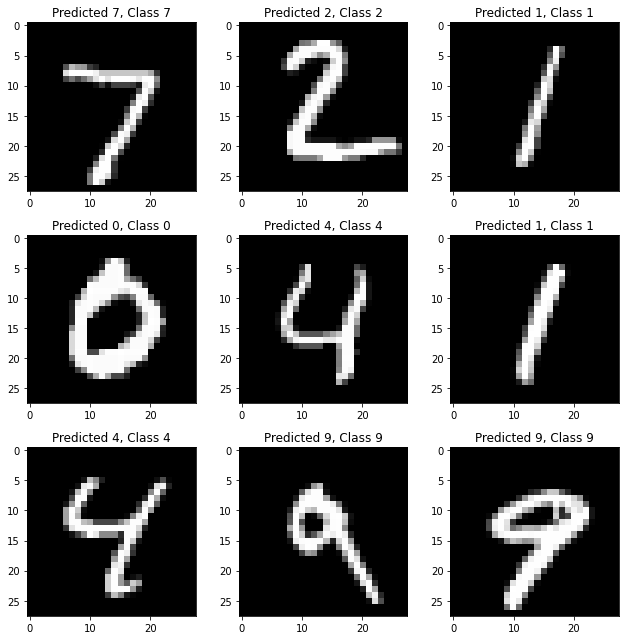

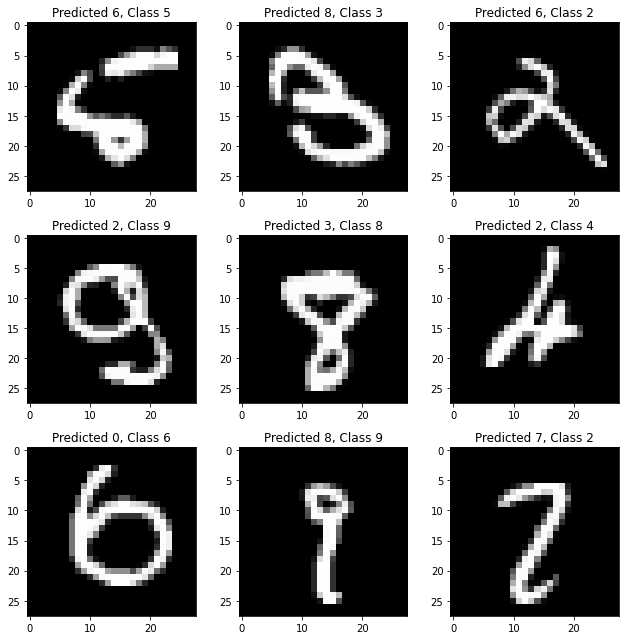

In [18]:
plt.figure()
for i, correct in enumerate(correct_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[correct].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[correct], np.argmax(y_test[correct])))
    
plt.tight_layout()
    
plt.figure()
for i, incorrect in enumerate(incorrect_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[incorrect].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[incorrect], np.argmax(y_test[incorrect])))
    
plt.tight_layout()

Ответ на вопросы:
1. Какую точность показала модель при исходном числе эпох?
   При исходном числе эпох модель показала точность 96,36%
2. Как изменилась точность при меньшем и большем числе эпох? Что вы заметили?
   При уменьшении числа эпох до 1 модель показала точность 94,53%
   При увеличении числа эпох до 10 модель показала точность 96,73%
   Из этого можно сделать вывод, что при увеличении числа эпох точность возрастает. После первой эпохи accuracy составила 0.9453, что ниже остальных результатов. При пяти эпохах accuracy выросла до 0.9636, однако при 10 эпохах она составила 0.9673, что говорит о том, что после 5 эпох прирост точности становится небольшим
3. Анализ неправильного предсказания
   Давайте рассмотрим несколько примеров из неправильного предсказания:
   Predicted 4, Class 8. На изображении восьмерка написана нестандартно: верхняя часть имеет угловатую несоединенную форму, которая очень напоминает цифру 4, а нижняя часть слегка вытянута вниз и чуть "сплющена" в правую сторону. Из-за таких особенностей написания нейросеть выделала признаки, характерные для цифры 4 и допустила ошибку.
   Predicted 6, Class 0. Нейросеть считала 6 вместо 0, интересно почему. Тут даже я засомневалась бы.
   Upd: я перезапускала полностью ноутбук несколько раз, так что показываются другие предсказания)

Доп задание

0.png -> 0 0.9999975
1.png -> 1 0.98776764
2.png -> 2 0.99999833
3.png -> 3 0.9999852
4.png -> 4 0.99824995
5.png -> 5 0.9999958
6.png -> 6 0.99044645
7.png -> 7 0.9999981
8.png -> 8 0.9994066
9.png -> 3 0.98525596


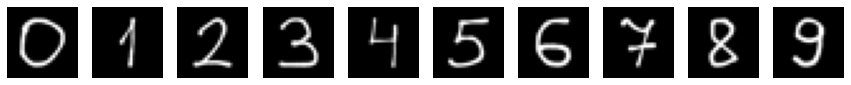

In [19]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

files = [
    "/kaggle/input/datasets/wejunn/numbersss/numbers/0.png",
    "/kaggle/input/datasets/wejunn/numbersss/numbers/1.png",
    "/kaggle/input/datasets/wejunn/numbersss/numbers/2.png",
    "/kaggle/input/datasets/wejunn/numbersss/numbers/3.png",
    "/kaggle/input/datasets/wejunn/numbersss/numbers/4.png",
    "/kaggle/input/datasets/wejunn/numbersss/numbers/5.png",
    "/kaggle/input/datasets/wejunn/numbersss/numbers/6.png",
    "/kaggle/input/datasets/wejunn/numbersss/numbers/7.png",
    "/kaggle/input/datasets/wejunn/numbersss/numbers/8.png",
    "/kaggle/input/datasets/wejunn/numbersss/numbers/9.png"
]


plt.figure(figsize=(15,3))

for i, file in enumerate(files):

    img = Image.open(file).convert("L")
    img = np.array(img)

    # делаем настоящий черный фон
    img[img < 150] = 0
    img[img >= 150] = 255

    pts = np.argwhere(img == 255)

    y0, x0 = pts.min(axis=0)
    y1, x1 = pts.max(axis=0) + 1

    img = img[y0:y1, x0:x1]

    h, w = img.shape
    size = max(h, w) + 20

    canvas = np.zeros((size, size), dtype=np.uint8)

    yy = (size - h) // 2
    xx = (size - w) // 2

    canvas[yy:yy+h, xx:xx+w] = img

    canvas = Image.fromarray(canvas)
    canvas = canvas.resize((20,20))

    final = np.zeros((28,28), dtype=np.uint8)
    final[4:24,4:24] = np.array(canvas)

    plt.subplot(1,10,i+1)
    plt.imshow(final, cmap="gray")
    plt.axis("off")

    sample = final.astype("float32").reshape(1,784)

    pred = model.predict(sample, verbose=0)

    print(file.split("/")[-1], "->", np.argmax(pred), np.max(pred))

Вывод:

В ходе эксперимента модель успешно распознала почти все подготовленные изображения собственных рукописных цифр. Для большинства цифр вероятность правильного распознавания превысила 98–99%, что свидетельствует о высокой уверенности модели. Наименьшая уверенность была получена при распознавании цифры 9 (около 40%) и модель допустила ошибку. Результаты показывают, что после правильной предварительной обработки изображений (бинаризация, центрирование и приведение к формату MNIST) обученная нейросеть эффективно распознаёт рукописные цифры.